# 01 — Data Cleaning & EDA
## Dataset: Fraud detection 1M transactions · 7 fraud types

**Mục tiêu Phase 1**:
- Hiểu cấu trúc 5 file dữ liệu
- Làm sạch dữ liệu
- Phân tích phân phối, class imbalance, fraud rings & network
- Chuẩn bị insight cho Feature Engineering + Graph Score

**Files kỳ vọng**:
```
transactions.csv
network_edges.csv
account_profiles.csv
fraud_patterns.csv
time_series_stats.csv
```

## 0. Setup & Imports

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional but recommended
try:
    import missingno as msno
except ImportError:
    msno = None
    print("missingno chưa cài → pip install missingno")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ====== CẤU HÌNH ĐƯỜNG DẪN ======
# Sửa lại cho đúng máy của bạn
DATA_DIR = Path("../data/raw/fraud_1m")          # thư mục chứa 5 file csv
PROCESSED_DIR = Path("../data/processed/frau_1m_processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR exists:", DATA_DIR.exists())
print("Files in DATA_DIR:")
if DATA_DIR.exists():
    for f in sorted(DATA_DIR.glob("*")):
        print(f"  - {f.name} ({f.stat().st_size / 1e6:.1f} MB)")

DATA_DIR exists: True
Files in DATA_DIR:
  - account_profiles.csv (6.2 MB)
  - fraud_patterns.csv (0.0 MB)
  - network_edges.csv (0.3 MB)
  - time_series_stats.csv (1.6 MB)
  - transactions.csv (128.2 MB)


## 1. Load dữ liệu

In [3]:
def load_csv(name: str, **kwargs) -> pd.DataFrame:
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy: {path}")
    df = pd.read_csv(path, **kwargs)
    print(f"Loaded {name:30s} → {df.shape[0]:>10,} rows × {df.shape[1]} cols")
    return df

# Load tất cả file
tx = load_csv("transactions.csv")
edges = load_csv("network_edges.csv")
accounts = load_csv("account_profiles.csv")
patterns = load_csv("fraud_patterns.csv")
ts_stats = load_csv("time_series_stats.csv")   # có thể không có → comment nếu lỗi

Loaded transactions.csv               →  1,000,000 rows × 23 cols
Loaded network_edges.csv              →      7,411 rows × 6 cols
Loaded account_profiles.csv           →     50,000 rows × 23 cols
Loaded fraud_patterns.csv             →          7 rows × 12 cols
Loaded time_series_stats.csv          →     26,280 rows × 10 cols


In [4]:
# Xem nhanh 5 dòng đầu mỗi bảng
display(tx.head())
print("\n--- network_edges ---")
display(edges.head())
print("\n--- account_profiles ---")
display(accounts.head())
print("\n--- fraud_patterns ---")
display(patterns.head())

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,card_present,device_type,device_known,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.420,travel,4511,CA,0,mobile_app,1,53.200,1,21,3,2.642,3256,1,3958.460,0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.780,online_retail,5999,AU,0,web_browser,1,25.300,1,234,1,0.728,1527,1,3553.350,0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.150,pharmacy,5912,CA,0,web_browser,1,21.300,1,85,1,0.185,2230,1,4362.570,0,NaN
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.490,grocery,5411,US,0,mobile_app,1,13.700,0,98,0,1.522,1863,1,3194.840,0,NaN
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.680,online_retail,5999,US,0,web_browser,1,9.700,0,721,2,0.772,1728,0,11850.060,0,NaN



--- network_edges ---


,account_a,account_b,shared_type,connection_count,ring_id,both_fraud
0,ACC0017803,ACC0040032,phone,7,RING0001,1
1,ACC0017803,ACC0042246,email_domain,12,RING0001,1
2,ACC0017803,ACC0029491,phone,13,RING0001,1
3,ACC0017803,ACC0022213,phone,12,RING0001,1
4,ACC0017803,ACC0007601,ip_address,14,RING0001,1



--- account_profiles ---


,account_id,account_age_days,credit_limit,home_country,risk_score,is_high_risk,avg_txn_amount,avg_monthly_txns,has_2fa,account_type,total_transactions,total_amount,avg_amount,max_amount,fraud_count,fraud_amount,pct_foreign,avg_velocity,unique_countries,unique_categories,avg_ip_risk,fraud_rate,is_fraudster
0,ACC0000001,353,2171.420,US,16.500,0,90.820,71.100,1,personal,49.000,7246.600,147.890,740.460,0.000,0.000,0.350,1.270,9.000,11.000,22.980,0.000,0.000
1,ACC0000002,2831,3031.380,US,25.400,0,63.780,7.400,1,business,2.000,280.790,140.390,186.130,1.000,186.130,0.500,4.000,2.000,2.000,52.450,0.500,1.000
2,ACC0000003,2399,7533.750,US,10.600,0,72.180,31.900,0,personal,18.000,4435.690,246.430,1175.860,0.000,0.000,0.170,1.440,3.000,8.000,15.500,0.000,0.000
3,ACC0000004,1618,4821.940,US,20.700,0,53.640,16.600,1,personal,18.000,5824.480,323.580,2753.310,0.000,0.000,0.330,1.110,4.000,10.000,19.010,0.000,0.000
4,ACC0000005,1597,3355.100,US,30.600,0,168.440,32.000,1,personal,19.000,3849.750,202.620,718.610,0.000,0.000,0.420,0.950,7.000,12.000,26.710,0.000,0.000



--- fraud_patterns ---


,fraud_pattern,description,transaction_count,fraud_share_pct,avg_amount,median_amount,pct_night_0_5,pct_foreign,pct_card_not_present,avg_velocity_1h,avg_ip_risk,pct_no_2fa
0,card_not_present,Online/CNP fraud — stolen card details used wi...,5982,34.890,771.780,268.630,41.320,58.060,73.120,3.980,55.260,42.240
1,account_takeover,Fraudster gains access to legitimate account v...,3432,20.020,1203.130,436.780,40.880,59.640,74.240,3.960,55.890,41.720
2,card_present_stolen,Physical card stolen and used at POS terminals,3120,18.200,556.840,200.270,40.830,57.240,73.170,3.950,54.990,40.610
3,friendly_fraud,Legitimate cardholder disputes valid transacti...,1726,10.070,352.610,120.800,38.990,55.970,74.680,3.930,54.910,42.470
4,atm_fraud,ATM skimming or card trapping to clone card,1216,7.090,466.260,164.530,40.870,60.440,76.230,4.040,55.600,39.390


## 2. Cấu trúc & Metadata cơ bản

In [9]:
def basic_info(df: pd.DataFrame, name: str):
    print(f"\n{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    print("\nDtypes:")
    print(df.dtypes.value_counts())
    print("\nColumns:")
    print(df.columns.tolist())

basic_info(tx, "transactions")



 transactions
Shape        : 1,000,000 rows × 23 columns
Memory usage : 516.6 MB

Dtypes:
int64      12
object      7
float64     4
Name: count, dtype: int64

Columns:
['transaction_id', 'account_id', 'timestamp', 'hour_of_day', 'day_of_week', 'is_weekend', 'amount', 'merchant_category', 'mcc_code', 'merchant_country', 'card_present', 'device_type', 'device_known', 'ip_risk_score', 'is_foreign_txn', 'time_since_last_s', 'velocity_1h', 'amount_vs_avg_ratio', 'account_age_days', 'has_2fa', 'credit_limit', 'is_fraud', 'fraud_pattern']


In [10]:
basic_info(edges, "network_edges")


 network_edges
Shape        : 7,411 rows × 6 columns
Memory usage : 1.8 MB

Dtypes:
object    4
int64     2
Name: count, dtype: int64

Columns:
['account_a', 'account_b', 'shared_type', 'connection_count', 'ring_id', 'both_fraud']


In [11]:
basic_info(accounts, "account_profiles")


 account_profiles
Shape        : 50,000 rows × 23 columns
Memory usage : 16.3 MB

Dtypes:
float64    17
object      3
int64       3
Name: count, dtype: int64

Columns:
['account_id', 'account_age_days', 'credit_limit', 'home_country', 'risk_score', 'is_high_risk', 'avg_txn_amount', 'avg_monthly_txns', 'has_2fa', 'account_type', 'total_transactions', 'total_amount', 'avg_amount', 'max_amount', 'fraud_count', 'fraud_amount', 'pct_foreign', 'avg_velocity', 'unique_countries', 'unique_categories', 'avg_ip_risk', 'fraud_rate', 'is_fraudster']


In [ ]:
# Thông tin chi tiết hơn
tx.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   transaction_id       1000000 non-null  object        
 1   account_id           1000000 non-null  category      
 2   timestamp            1000000 non-null  datetime64[ns]
 3   hour_of_day          1000000 non-null  int64         
 4   day_of_week          1000000 non-null  int64         
 5   is_weekend           1000000 non-null  int64         
 6   amount               1000000 non-null  float64       
 7   merchant_category    1000000 non-null  object        
 8   mcc_code             1000000 non-null  int64         
 9   merchant_country     1000000 non-null  object        
 10  card_present         1000000 non-null  int64         
 11  device_type          1000000 non-null  object        
 12  device_known         1000000 non-null  int64         
 13

In [13]:
edges.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7411 entries, 0 to 7410
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   account_a         7411 non-null   object
 1   account_b         7411 non-null   object
 2   shared_type       7411 non-null   object
 3   connection_count  7411 non-null   int64 
 4   ring_id           4411 non-null   object
 5   both_fraud        7411 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 1.7 MB


In [14]:
accounts.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   account_id          50000 non-null  object 
 1   account_age_days    50000 non-null  int64  
 2   credit_limit        50000 non-null  float64
 3   home_country        50000 non-null  object 
 4   risk_score          50000 non-null  float64
 5   is_high_risk        50000 non-null  int64  
 6   avg_txn_amount      50000 non-null  float64
 7   avg_monthly_txns    50000 non-null  float64
 8   has_2fa             50000 non-null  int64  
 9   account_type        50000 non-null  object 
 10  total_transactions  50000 non-null  float64
 11  total_amount        50000 non-null  float64
 12  avg_amount          50000 non-null  float64
 13  max_amount          50000 non-null  float64
 14  fraud_count         50000 non-null  float64
 15  fraud_amount        50000 non-null  float64
 16  pct_

## 3. Data Cleaning

### 3.1 Missing values

In [16]:
def missing_report(df: pd.DataFrame, top_n: int = 20):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({"missing": miss, "pct": miss_pct})
    report = report[report["missing"] > 0].sort_values("pct", ascending=False)
    print(f"Số cột có missing: {len(report)} / {df.shape[1]}")
    if len(report) > 0:
        display(report.head(top_n))
    else:
        print("→ Không có missing values.")
    return report

print("=== transactions ===")
miss_tx = missing_report(tx)


=== transactions ===
Số cột có missing: 1 / 23


,missing,pct
fraud_pattern,982857,98.290


In [17]:
print("\n=== network_edges ===")
miss_edges = missing_report(edges)


=== network_edges ===
Số cột có missing: 1 / 6


,missing,pct
ring_id,3000,40.480


In [18]:
print("\n=== account_profiles ===")
miss_acc = missing_report(accounts)


=== account_profiles ===
Số cột có missing: 0 / 23
→ Không có missing values.


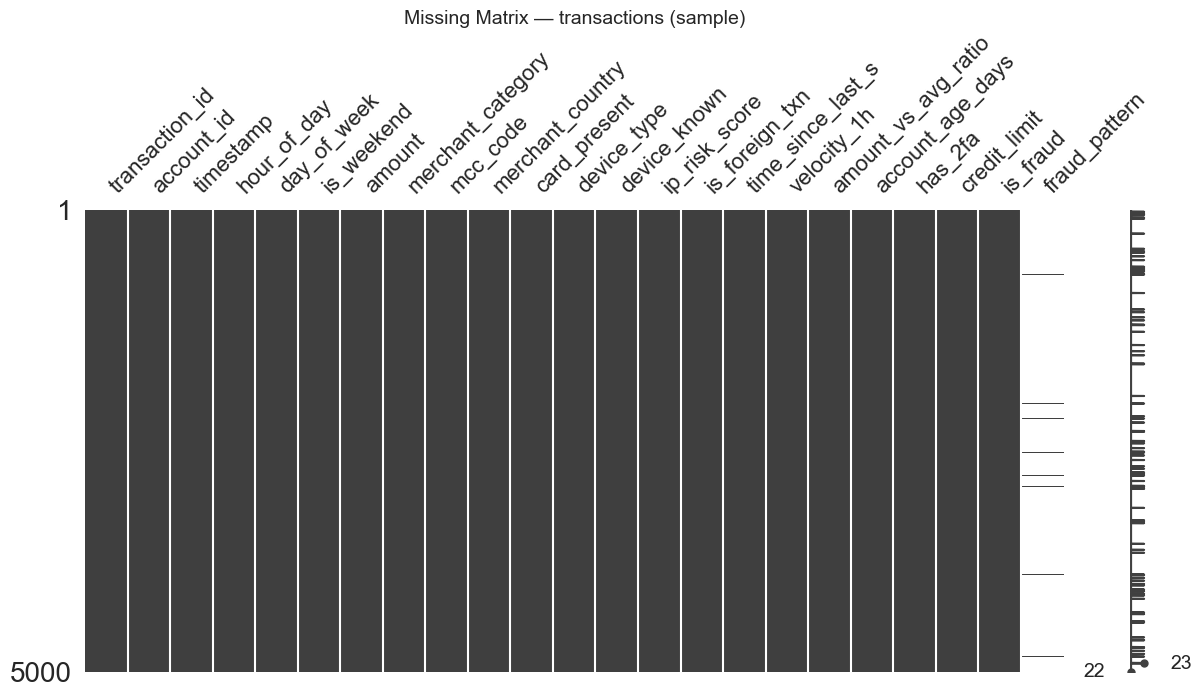

In [19]:
# Visualize missing (nếu có missingno)
if msno is not None and miss_tx is not None and len(miss_tx) > 0:
    msno.matrix(tx.sample(min(5000, len(tx))), figsize=(14, 6))
    plt.title("Missing Matrix — transactions (sample)")
    plt.show()

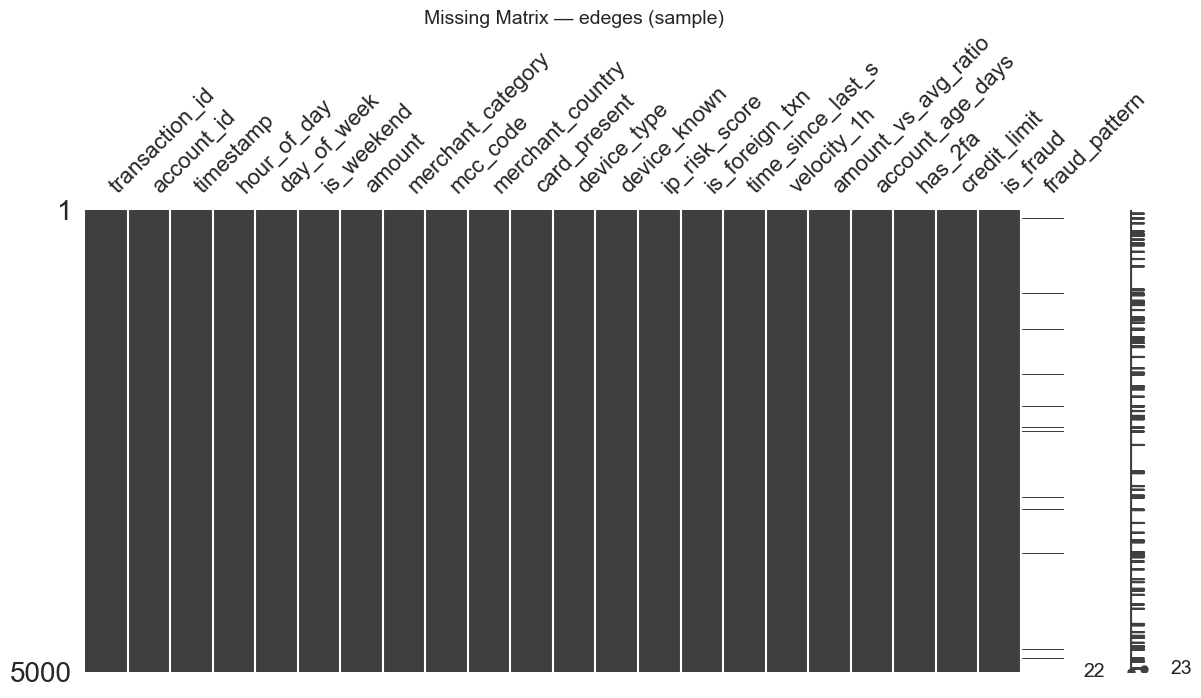

In [21]:
if msno is not None and miss_edges is not None and len(miss_edges) > 0:
    msno.matrix(tx.sample(min(5000, len(tx))), figsize=(14, 6))
    plt.title("Missing Matrix — edeges (sample)")
    plt.show()

### 3.2 Duplicates

In [24]:
# Kiểm tra duplicate
print("transactions — duplicate rows     :", tx.duplicated().sum())
print("transactions — duplicate tx_id    :", tx.duplicated(subset=["transaction_id"]).sum() if "transaction_id" in tx.columns else "N/A")

print("\nnetwork_edges — duplicate rows   :", edges.duplicated().sum())
print("account_profiles — duplicate rows:", accounts.duplicated().sum())

transactions — duplicate rows     : 0
transactions — duplicate tx_id    : 0

network_edges — duplicate rows   : 0
account_profiles — duplicate rows: 0


### 3.3 Kiểu dữ liệu & chuyển đổi

In [34]:
# 1. Timestamp
tx["timestamp"] = pd.to_datetime(tx["timestamp"], errors="coerce")
print("timestamp →", tx["timestamp"].dtype)

# 2. Target
tx["is_fraud"] = tx["is_fraud"].astype("int8")

# 3. Các cột categorical / ID (giảm memory rất nhiều)
cat_cols_tx = [
    "account_id",
    "merchant_category",
    "merchant_country",
    "device_type",
    "fraud_pattern",          # dù missing nhiều vẫn nên để category
]

for col in cat_cols_tx:
    if col in tx.columns:
        tx[col] = tx[col].astype("category")

# 4. Các cột boolean / flag nên để int8
flag_cols = [
    "is_weekend",
    "card_present",
    "device_known",
    "is_foreign_txn",
    "has_2fa",
]

for col in flag_cols:
    if col in tx.columns:
        tx[col] = tx[col].astype("int8")

# 5. Các cột số nguyên nhỏ
int_cols = ["hour_of_day", "day_of_week", "mcc_code", "account_age_days"]
for col in int_cols:
    if col in tx.columns:
        tx[col] = pd.to_numeric(tx[col], errors="coerce").astype("Int32")  # nullable int

# 6. network_edges
edges["account_a"] = edges["account_a"].astype("category")
edges["account_b"] = edges["account_b"].astype("category")
edges["shared_type"] = edges["shared_type"].astype("category")
edges["ring_id"] = edges["ring_id"].astype("category")          # có missing 40% → category vẫn ổn
edges["both_fraud"] = edges["both_fraud"].astype("int8")
edges["connection_count"] = edges["connection_count"].astype("int16")

# 7. account_profiles (tùy chọn, làm luôn cho đồng bộ)
accounts["account_id"] = accounts["account_id"].astype("category")
accounts["home_country"] = accounts["home_country"].astype("category")
accounts["account_type"] = accounts["account_type"].astype("category")
accounts["is_high_risk"] = accounts["is_high_risk"].astype("int8")
accounts["has_2fa"] = accounts["has_2fa"].astype("int8")
accounts["is_fraudster"] = accounts["is_fraudster"].astype("int8")

print("\nĐã convert xong.")
print("\nDtypes transactions sau convert:")
print(tx.dtypes)
print(f"\nMemory transactions sau convert: {tx.memory_usage(deep=True).sum()/1e6:.1f} MB")

timestamp → datetime64[ns]

Đã convert xong.

Dtypes transactions sau convert:
transaction_id                 object
account_id                   category
timestamp              datetime64[ns]
hour_of_day                     Int32
day_of_week                     Int32
is_weekend                       int8
amount                        float64
merchant_category            category
mcc_code                        Int32
merchant_country             category
card_present                     int8
device_type                  category
device_known                     int8
ip_risk_score                 float64
is_foreign_txn                   int8
time_since_last_s               int64
velocity_1h                     int64
amount_vs_avg_ratio           float64
account_age_days                Int32
has_2fa                          int8
credit_limit                  float64
is_fraud                         int8
fraud_pattern                category
dtype: object

Memory transactions sau convert:

### 3.4 Kiểm tra logic & giá trị bất thường

In [35]:
# Thêm kiểm tra logic
print("is_fraud value counts:")
print(tx["is_fraud"].value_counts())

print("\nFraud rate: {:.3f}%".format(tx["is_fraud"].mean() * 100))

print("\nvelocity_1h describe:")
print(tx["velocity_1h"].describe())

print("\namount_vs_avg_ratio describe:")
print(tx["amount_vs_avg_ratio"].describe())

print("\nip_risk_score describe:")
print(tx["ip_risk_score"].describe())

# Kiểm tra tính nhất quán network
tx_accounts = set(tx["account_id"].unique())
edge_accounts = set(edges["account_a"]).union(set(edges["account_b"]))
print(f"\nAccounts in transactions : {len(tx_accounts):,}")
print(f"Accounts in edges        : {len(edge_accounts):,}")
print(f"Overlap                  : {len(tx_accounts & edge_accounts):,}")
print(f"Edge accounts not in tx  : {len(edge_accounts - tx_accounts):,}")

is_fraud value counts:
is_fraud
0    982857
1     17143
Name: count, dtype: int64

Fraud rate: 1.714%

velocity_1h describe:
count   1000000.000
mean          1.050
std           1.095
min           0.000
25%           0.000
50%           1.000
75%           2.000
max          15.000
Name: velocity_1h, dtype: float64

amount_vs_avg_ratio describe:
count   1000000.000
mean          3.299
std           7.157
min           0.012
25%           0.597
50%           1.285
75%           3.155
max         945.537
Name: amount_vs_avg_ratio, dtype: float64

ip_risk_score describe:
count   1000000.000
mean         21.606
std          16.270
min           0.000
25%           8.500
50%          18.700
75%          30.700
max         100.000
Name: ip_risk_score, dtype: float64

Accounts in transactions : 49,903
Accounts in edges        : 6,783
Overlap                  : 6,783
Edge accounts not in tx  : 0


### 3.5 Lưu bản đã clean (tùy chọn)

In [40]:
import pandas as pd
from pathlib import Path

def safe_to_parquet(df: pd.DataFrame, path: Path):
    """Xử lý triệt để các kiểu dữ liệu nâng cao của Pandas (category, period, object, extension int)
    trước khi lưu bằng PyArrow để tránh xung đột ArrowKeyError.
    """
    df_save = df.copy()
    
    # 1. Chuyển Category & Period & Object thành String chuẩn của Pandas
    for col in df_save.columns:
        dtype_str = str(df_save[col].dtype).lower()
        
        # Xử lý Category, Period, hoặc Object tổng quát
        if "category" in dtype_str or "period" in dtype_str or dtype_str == "object":
            df_save[col] = df_save[col].astype(str)
            
    # 2. Chuyển Nullable Integers (Int8, Int16, Int32, Int64) -> float64 để giữ NaN an toàn
    for col in df_save.select_dtypes(include=["Int8", "Int16", "Int32", "Int64"]).columns:
        df_save[col] = df_save[col].astype("float64")
    
    # 3. Ghi file với pyarrow (Truyền pyarrow table trực tiếp để bypass extension registry bị lặp)
    try:
        df_save.to_parquet(path, index=False, engine="pyarrow")
    except Exception:
        # Fallback an toàn sang fastparquet nếu PyArrow environment vẫn bị kẹt registry
        df_save.to_parquet(path, index=False, engine="fastparquet")
        
    print(f"Saved: {path}  ({path.stat().st_size / 1e6:.1f} MB)")


# Lưu 3 file
safe_to_parquet(tx, PROCESSED_DIR / "transactions_clean.parquet")
safe_to_parquet(edges, PROCESSED_DIR / "network_edges_clean.parquet")
safe_to_parquet(accounts, PROCESSED_DIR / "account_profiles_clean.parquet")

print("\n✅ Đã lưu thành công vào", PROCESSED_DIR)

Saved: ..\data\processed\transactions_clean.parquet  (63.0 MB)
Saved: ..\data\processed\network_edges_clean.parquet  (0.1 MB)
Saved: ..\data\processed\account_profiles_clean.parquet  (3.2 MB)

✅ Đã lưu thành công vào ..\data\processed


## 4. Exploratory Data Analysis

### 4.1 Target Distribution

Target value counts:
is_fraud
0    982857
1     17143
Name: count, dtype: int64

Fraud rate: 1.714%


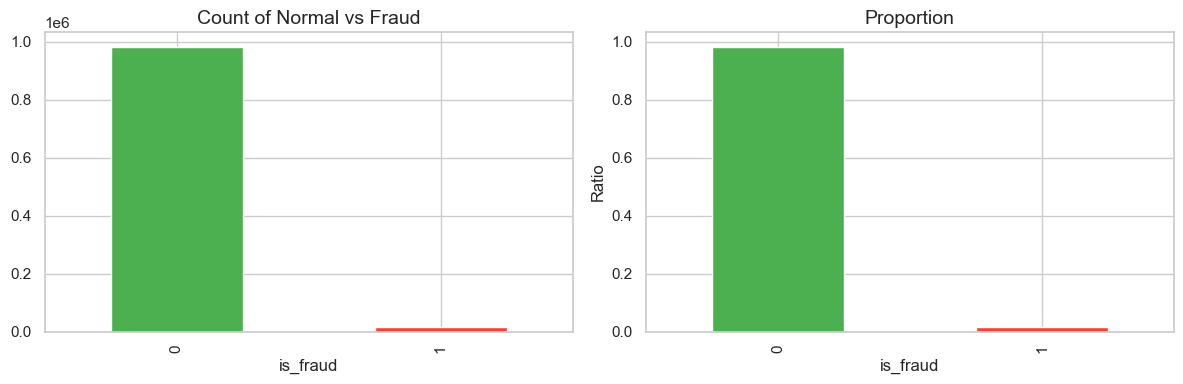

In [41]:
# Xác định cột target (chỉnh nếu tên khác)
TARGET = "is_fraud" if "is_fraud" in tx.columns else "fraud_label"

print("Target value counts:")
print(tx[TARGET].value_counts())
print(f"\nFraud rate: {tx[TARGET].mean()*100:.3f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
tx[TARGET].value_counts().plot(kind="bar", ax=ax[0], color=["#4caf50", "#f44336"])
ax[0].set_title("Count of Normal vs Fraud")
ax[0].set_xlabel(TARGET)

tx[TARGET].value_counts(normalize=True).plot(kind="bar", ax=ax[1], color=["#4caf50", "#f44336"])
ax[1].set_title("Proportion")
ax[1].set_ylabel("Ratio")
plt.tight_layout()
plt.show()

### 4.2 Fraud Pattern (7 loại)

fraud_pattern
NaN                    982857
card_not_present         5982
account_takeover         3432
card_present_stolen      3120
friendly_fraud           1726
atm_fraud                1216
money_laundering         1011
identity_theft            656
Name: count, dtype: int64


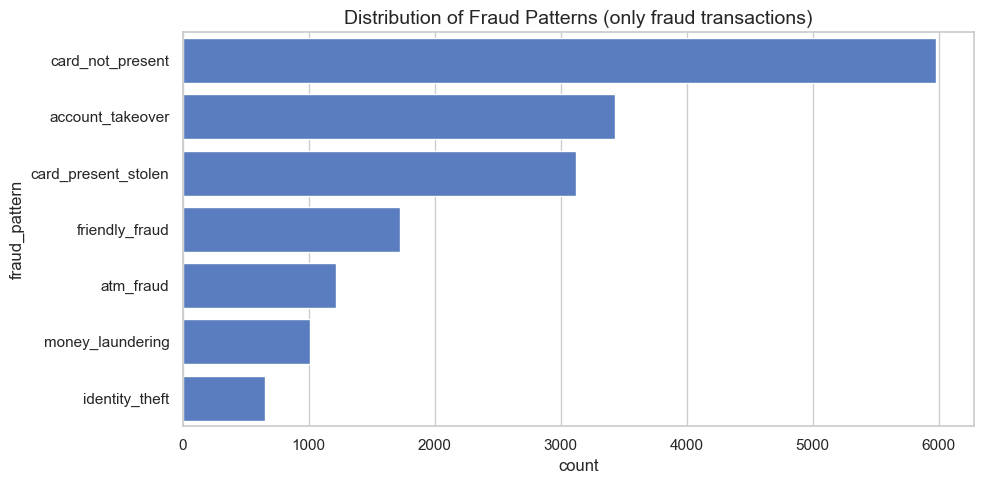

In [42]:
PATTERN_COL = None
for c in ["fraud_pattern", "fraud_type", "pattern"]:
    if c in tx.columns:
        PATTERN_COL = c
        break

if PATTERN_COL:
    print(tx[PATTERN_COL].value_counts(dropna=False))
    plt.figure(figsize=(10, 5))
    sns.countplot(data=tx[tx[TARGET] == 1], y=PATTERN_COL, order=tx[tx[TARGET]==1][PATTERN_COL].value_counts().index)
    plt.title("Distribution of Fraud Patterns (only fraud transactions)")
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy cột fraud_pattern / fraud_type")

### 4.3 Amount Distribution

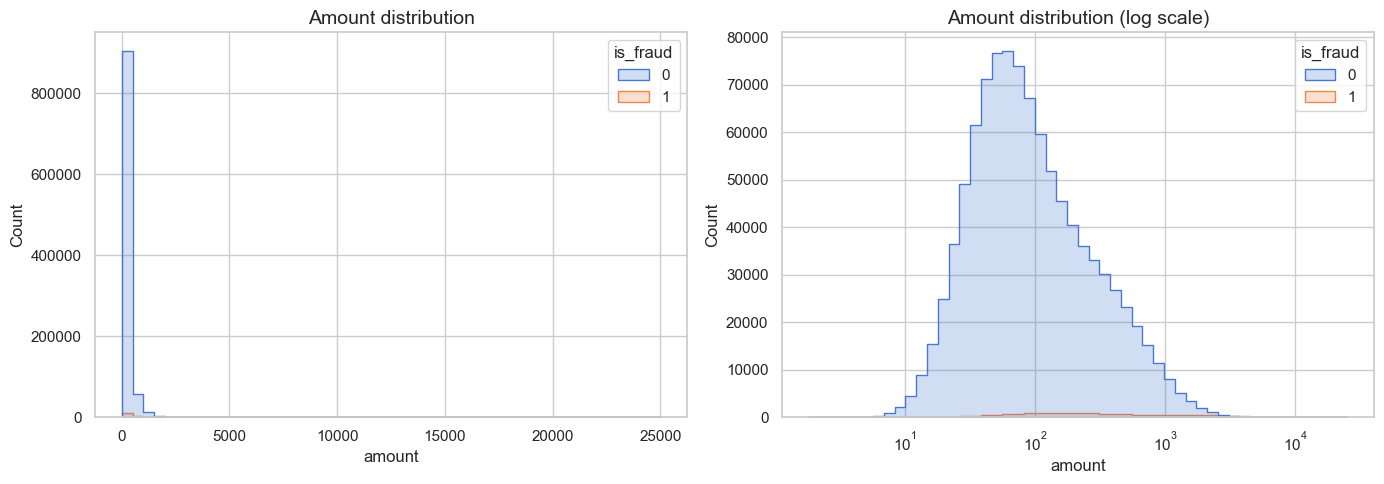


Amount by target:
              count    mean      std   min     25%     50%     75%       max
is_fraud                                                                    
0        982857.000 174.208  264.914 1.830  43.160  80.030 185.050  8930.270
1         17143.000 730.137 1234.193 1.940 100.235 240.740 813.225 25000.000


In [43]:
if "amount" in tx.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Linear scale
    sns.histplot(data=tx, x="amount", hue=TARGET, bins=50, ax=axes[0], element="step")
    axes[0].set_title("Amount distribution")

    # Log scale
    sns.histplot(data=tx[tx["amount"] > 0], x="amount", hue=TARGET, bins=50, log_scale=True, ax=axes[1], element="step")
    axes[1].set_title("Amount distribution (log scale)")

    plt.tight_layout()
    plt.show()

    print("\nAmount by target:")
    print(tx.groupby(TARGET)["amount"].describe())

### 4.4 Thời gian (nếu có timestamp)

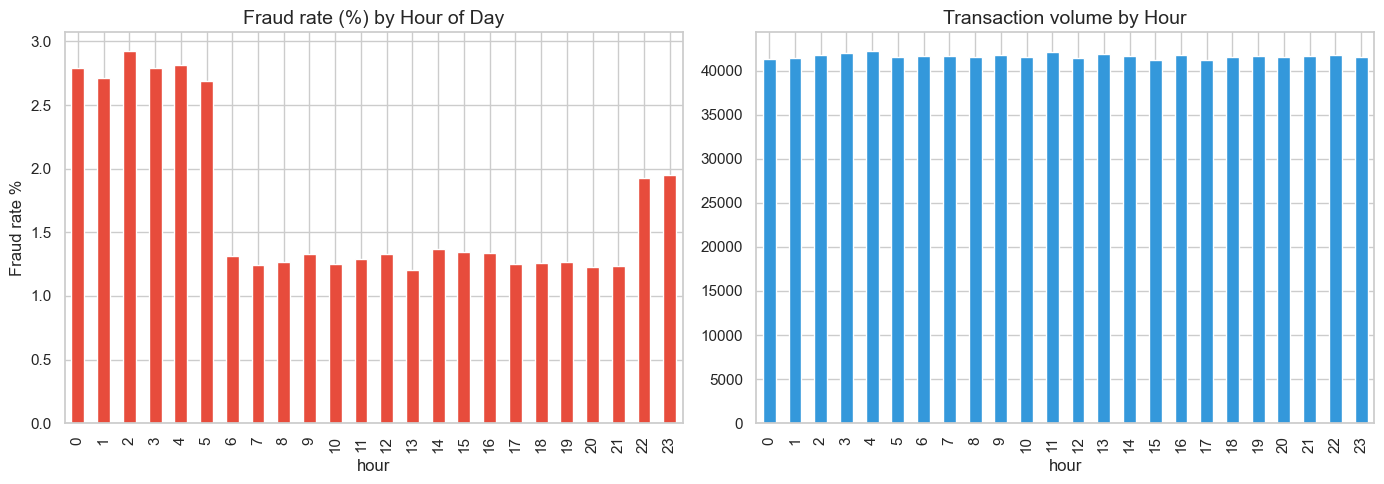

In [44]:
if "timestamp" in tx.columns and pd.api.types.is_datetime64_any_dtype(tx["timestamp"]):
    tx["hour"] = tx["timestamp"].dt.hour
    tx["dayofweek"] = tx["timestamp"].dt.dayofweek
    tx["date"] = tx["timestamp"].dt.date

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Fraud rate theo giờ
    hourly = tx.groupby("hour")[TARGET].mean() * 100
    hourly.plot(kind="bar", ax=axes[0], color="#e74c3c")
    axes[0].set_title("Fraud rate (%) by Hour of Day")
    axes[0].set_ylabel("Fraud rate %")

    # Số lượng giao dịch theo giờ
    tx.groupby("hour").size().plot(kind="bar", ax=axes[1], color="#3498db")
    axes[1].set_title("Transaction volume by Hour")

    plt.tight_layout()
    plt.show()
else:
    print("Không có cột timestamp datetime → bỏ qua phần này")

### 4.5 Cardinality & Shared Entities (rất quan trọng cho Graph)

In [45]:
id_cols = [c for c in ["account_id", "device_id", "ip_address", "email", "card_id", "merchant_id"] if c in tx.columns]

print("Cardinality:")
for c in id_cols:
    print(f"  {c:20s}: {tx[c].nunique():>10,} unique")

Cardinality:
  account_id          :     49,903 unique


In [53]:
# Top shared devices / IPs (nếu có trong transactions)
for col in ["device_id", "ip_address"]:
    if col in tx.columns:
        shared = tx.groupby(col)["account_id"].nunique() if "account_id" in tx.columns else tx.groupby(col).size()
        top_shared = shared.sort_values(ascending=False).head(15)
        print(f"\nTop shared {col}:")
        print(top_shared)

### 4.6 Network Edges & Fraud Rings

In [47]:
print("network_edges shape:", edges.shape)
print("\nColumns:", edges.columns.tolist())
display(edges.head(10))

if "connection_type" in edges.columns:
    print("\nConnection type distribution:")
    print(edges["connection_type"].value_counts())

network_edges shape: (7411, 6)

Columns: ['account_a', 'account_b', 'shared_type', 'connection_count', 'ring_id', 'both_fraud']


,account_a,account_b,shared_type,connection_count,ring_id,both_fraud
0,ACC0017803,ACC0040032,phone,7,RING0001,1
1,ACC0017803,ACC0042246,email_domain,12,RING0001,1
2,ACC0017803,ACC0029491,phone,13,RING0001,1
3,ACC0017803,ACC0022213,phone,12,RING0001,1
4,ACC0017803,ACC0007601,ip_address,14,RING0001,1
5,ACC0040032,ACC0042246,phone,9,RING0001,1
6,ACC0040032,ACC0029491,phone,9,RING0001,1
7,ACC0040032,ACC0022213,email_domain,3,RING0001,1
8,ACC0040032,ACC0007601,ip_address,8,RING0001,1
9,ACC0042246,ACC0029491,email_domain,10,RING0001,1


Số fraud rings: 200

Ring size distribution:
count   200.000
mean     22.055
std      16.690
min       3.000
25%       6.000
50%      15.000
75%      36.000
max      55.000
dtype: float64


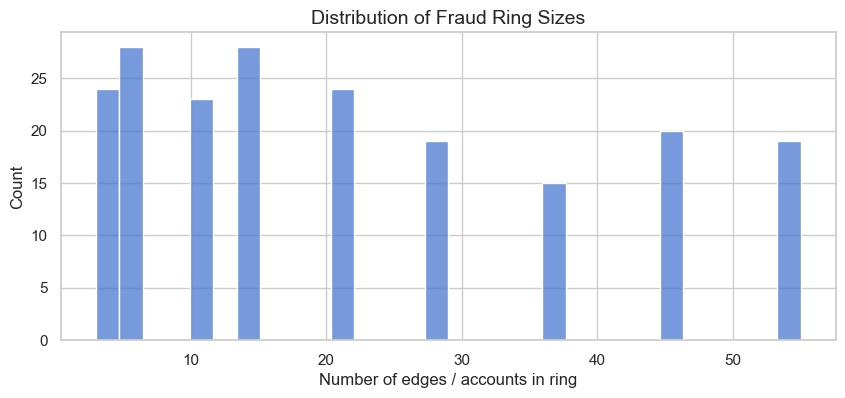

In [48]:
# Phân tích ring (nếu có ring_id)
if "ring_id" in edges.columns:
    ring_size = edges.groupby("ring_id").size()
    print("Số fraud rings:", edges["ring_id"].nunique())
    print("\nRing size distribution:")
    print(ring_size.describe())

    plt.figure(figsize=(10, 4))
    sns.histplot(ring_size, bins=30, kde=False)
    plt.title("Distribution of Fraud Ring Sizes")
    plt.xlabel("Number of edges / accounts in ring")
    plt.show()
else:
    print("Không có cột ring_id trong network_edges")

In [54]:
# Degree distribution sơ bộ
if {"src_account", "dst_account"}.issubset(edges.columns):
    degree = pd.concat([edges["src_account"], edges["dst_account"]]).value_counts()
    print("Degree describe:")
    print(degree.describe())

    plt.figure(figsize=(10, 4))
    sns.histplot(degree, bins=50, log_scale=(False, True))
    plt.title("Account Degree Distribution (log y)")
    plt.xlabel("Degree")
    plt.show()

### 4.7 Account Profiles

                       count unique         top   freq     mean      std  \
account_id             50000  50000  ACC0000001      1      NaN      NaN   
account_age_days   50000.000    NaN         NaN    NaN 1837.466 1045.951   
credit_limit       50000.000    NaN         NaN    NaN 6724.527 6167.106   
home_country           50000      1          US  50000      NaN      NaN   
risk_score         50000.000    NaN         NaN    NaN   19.912   12.006   
is_high_risk       50000.000    NaN         NaN    NaN    0.000    0.019   
avg_txn_amount     50000.000    NaN         NaN    NaN   79.767   51.861   
avg_monthly_txns   50000.000    NaN         NaN    NaN   25.628   20.153   
has_2fa            50000.000    NaN         NaN    NaN    0.649    0.477   
account_type           50000      3    personal  35061      NaN      NaN   
total_transactions 50000.000    NaN         NaN    NaN   20.000   16.335   
total_amount       50000.000    NaN         NaN    NaN 3674.765 3333.279   
avg_amount  

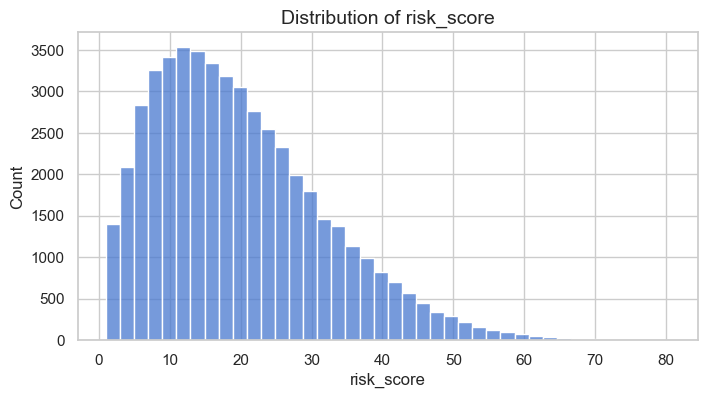

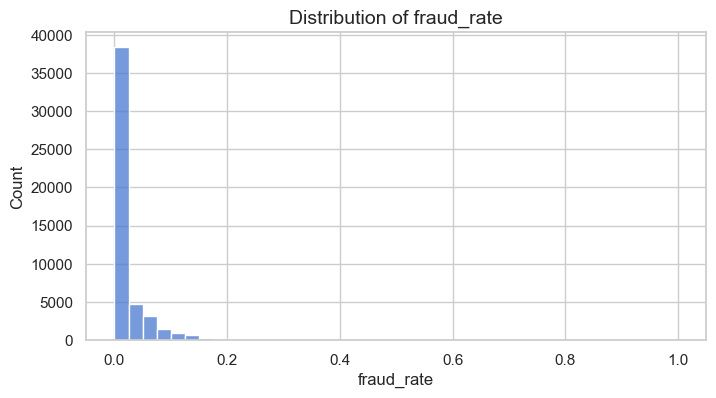

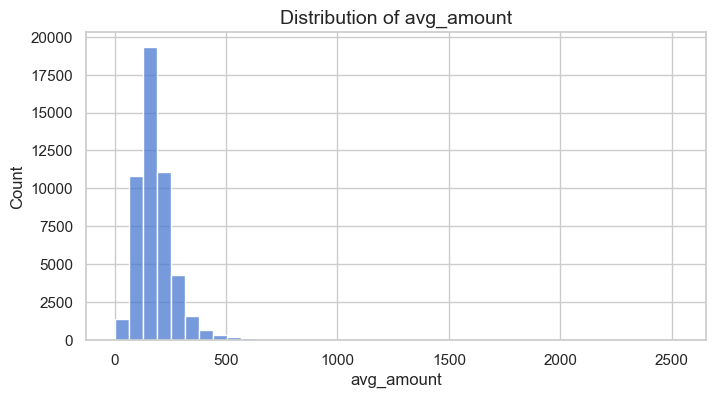

In [50]:
print(accounts.describe(include="all").T.head(20))

# Nếu có cột risk_score hoặc fraud_rate
for col in ["risk_score", "fraud_rate", "avg_amount", "tx_count"]:
    if col in accounts.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(accounts[col].dropna(), bins=40)
        plt.title(f"Distribution of {col}")
        plt.show()

### 4.8 Time Series Stats (nếu có)

In [51]:
if "ts_stats" in dir() and isinstance(ts_stats, pd.DataFrame):
    display(ts_stats.head())
    print(ts_stats.columns.tolist())
    # Ví dụ vẽ fraud rate theo thời gian nếu có cột phù hợp
else:
    print("Không load được time_series_stats → bỏ qua")

,hour,transaction_count,fraud_count,total_amount,avg_amount,avg_ip_risk,fraud_rate,hour_of_day,day_of_week,is_weekend
0,2022-01-01 00:00:00,40,1,9341.660,233.540,19.920,0.025,0,5,1
1,2022-01-01 01:00:00,43,0,6295.770,146.410,20.320,0.000,1,5,1
2,2022-01-01 02:00:00,41,1,10763.950,262.540,22.130,0.024,2,5,1
3,2022-01-01 03:00:00,34,0,9354.500,275.130,22.000,0.000,3,5,1
4,2022-01-01 04:00:00,39,2,5897.090,151.210,25.870,0.051,4,5,1


['hour', 'transaction_count', 'fraud_count', 'total_amount', 'avg_amount', 'avg_ip_risk', 'fraud_rate', 'hour_of_day', 'day_of_week', 'is_weekend']


## 5. Tổng hợp Insight (điền sau khi chạy EDA)

In [52]:
summary = {
    "total_transactions": len(tx),
    "fraud_rate_pct": round(tx[TARGET].mean() * 100, 3),
    "n_accounts": tx["account_id"].nunique() if "account_id" in tx.columns else None,
    "n_devices": tx["device_id"].nunique() if "device_id" in tx.columns else None,
    "n_ips": tx["ip_address"].nunique() if "ip_address" in tx.columns else None,
    "n_edges": len(edges),
    "n_rings": edges["ring_id"].nunique() if "ring_id" in edges.columns else None,
    "has_timestamp": "timestamp" in tx.columns,
    "pattern_col": PATTERN_COL,
}

print("=== SUMMARY ===")
for k, v in summary.items():
    print(f"{k:25s}: {v}")

=== SUMMARY ===
total_transactions       : 1000000
fraud_rate_pct           : 1.714
n_accounts               : 49903
n_devices                : None
n_ips                    : None
n_edges                  : 7411
n_rings                  : 200
has_timestamp            : True
pattern_col              : fraud_pattern


In [55]:
# Shared type
print(edges["shared_type"].value_counts())

# Fraud rate theo in_ring
ring_accounts = set(edges.dropna(subset=["ring_id"])["account_a"]) | set(edges.dropna(subset=["ring_id"])["account_b"])
tx["in_ring"] = tx["account_id"].isin(ring_accounts).astype(int)
print(tx.groupby("in_ring")["is_fraud"].agg(["count", "mean"]))

# Correlation
num_cols = ["amount", "velocity_1h", "amount_vs_avg_ratio", "ip_risk_score", 
            "time_since_last_s", "account_age_days", "credit_limit"]
print(tx[num_cols + ["is_fraud"]].corr()["is_fraud"].sort_values(ascending=False))

shared_type
ip_address      2134
device_id       2083
email_domain    2083
phone           1111
Name: count, dtype: int64
          count  mean
in_ring              
0        963426 0.016
1         36574 0.044
is_fraud               1.000
velocity_1h            0.352
ip_risk_score          0.274
amount                 0.228
amount_vs_avg_ratio    0.183
time_since_last_s      0.000
credit_limit          -0.001
account_age_days      -0.003
Name: is_fraud, dtype: float64
